In [47]:
import pandas as pd

In [48]:
import matplotlib.pyplot as plt

In [49]:
df = pd.read_excel("board2.xlsx")
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


A: VISAYAS COMMUNCIATON DATAFRAME

In [50]:
df["Average"] = (df["Math"] + df["Electronics"] + df["GEAS"] + df["Communication"]) / 4
df["Average"] = df["Average"].round(2)

print("Data loaded successfully")
print(df.head())

Data loaded successfully
  Name  Gender            Track  Hometown  Math  Electronics  GEAS  \
0   S1    Male  Instrumentation     Luzon    58           89    75   
1   S2  Female    Communication  Mindanao    52           75    90   
2   S3  Female  Instrumentation  Mindanao    83           74    77   
3   S4    Male  Instrumentation   Visayas    65           58    91   
4   S5    Male    Communication     Luzon    59           86    43   

   Communication  Average  
0             78    75.00  
1             52    67.25  
2             57    72.75  
3             68    70.50  
4             88    69.00  


In [51]:
visayas_students = df[df["Hometown"] == "Visayas"]

In [52]:
viscomm_students = visayas_students[visayas_students["Track"] == "Communication"]

In [53]:
VisComm = viscomm_students[["Name", "Gender", "Math", "Electronics", "Average"]]

print("A. VISAYAS COMMUNICATION DATAFRAME")
print(VisComm)
print(f"Number of rows: {len(VisComm)}")


A. VISAYAS COMMUNICATION DATAFRAME
   Name  Gender  Math  Electronics  Average
10  S11  Female    48           56    54.75
11  S12    Male    89           67    76.00
17  S18    Male    81           40    63.50
21  S22  Female    64           39    62.50
27  S28    Male    85           53    67.75
Number of rows: 5


###B: VISAYAS FEMALE DATA FRAME

In [54]:

visayas_students = df[df["Hometown"] == "Visayas"]
visfemale_students = visayas_students[visayas_students["Gender"] == "Female"]
VisFemale = visfemale_students[["Name", "Track", "GEAS", "Electronics", "Average"]]

print("B. VISAYAS FEMALE DATAFRAME")
print(VisFemale)
print(f"Number of rows: {len(VisFemale)}")

B. VISAYAS FEMALE DATAFRAME
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
10  S11     Communication    48           56    54.75
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
23  S24  Microelectronics    60           45    57.75
25  S26   Instrumentation    83           47    65.75
Number of rows: 6


In [55]:
passing_students = VisFemale[VisFemale["Average"] >= 60]

print("\nVis Female students with Average >= 60:")
print(passing_students)
print(f"Number of passing students: {len(passing_students)}")


Vis Female students with Average >= 60:
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
25  S26   Instrumentation    83           47    65.75
Number of passing students: 4


###C: CATEGORY-AVERAGE VISUALIZATION

In [56]:
track_means = df.groupby("Track")["Average"].mean().round(2)
gender_means = df.groupby("Gender")["Average"].mean().round(2)
hometown_means = df.groupby("Hometown")["Average"].mean().round(2)

print("Mean Average by Track:")
print(track_means)
print("\nMean Average by Gender:")
print(gender_means)
print("\nMean Average by Hometown:")
print(hometown_means)

Mean Average by Track:
Track
Communication       67.97
Instrumentation     65.22
Microelectronics    67.50
Name: Average, dtype: float64

Mean Average by Gender:
Gender
Female    66.62
Male      67.18
Name: Average, dtype: float64

Mean Average by Hometown:
Hometown
Luzon       68.08
Mindanao    66.68
Visayas     65.75
Name: Average, dtype: float64


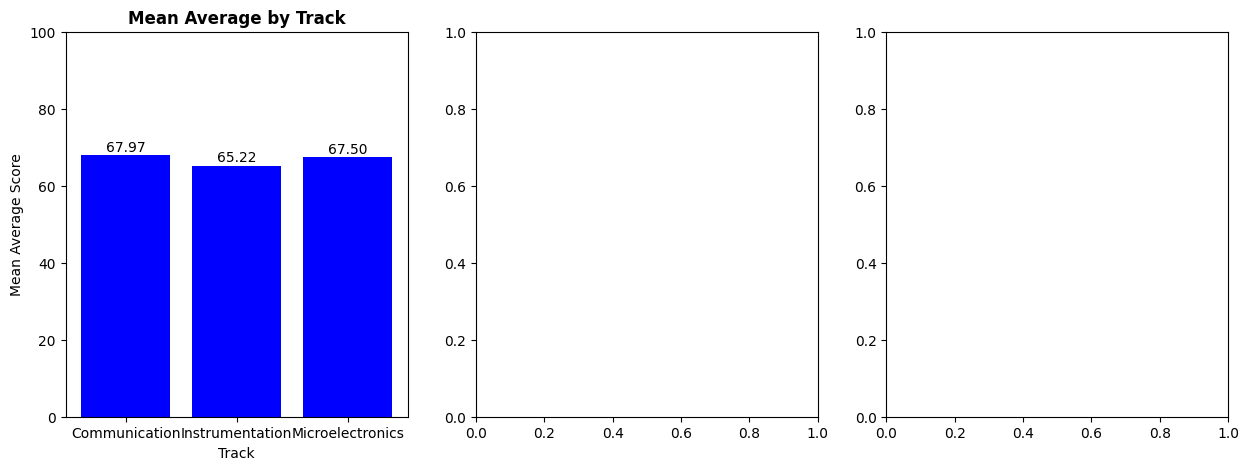

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(track_means.index, track_means.values, color="blue")
axes[0].set_title("Mean Average by Track", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average Score")
axes[0].set_ylim(0, 100)
for i, val in enumerate(track_means.values):
    axes[0].text(i, val + 1, f"{val:.2f}", ha="center")

In [58]:
axes[1].bar(gender_means.index, gender_means.values, color="orange")
axes[1].set_title("Mean Average by Gender", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Mean Average Score")
axes[1].set_ylim(0, 100)
for i, val in enumerate(gender_means.values):
    axes[1].text(i, val + 1, f"{val:.2f}", ha="center")

In [59]:
axes[2].bar(hometown_means.index, hometown_means.values, color="green")
axes[2].set_title("Mean Average by Hometown", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Hometown")
axes[2].set_ylabel("Mean Average Score")
axes[2].set_ylim(0, 100)
for i, val in enumerate(hometown_means.values):
    axes[2].text(i, val + 1, f"{val:.2f}", ha="center")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [60]:
track_highest = track_means.idxmax()
track_highest_value = track_means.max()

gender_highest = gender_means.idxmax()
gender_highest_value = gender_means.max()

hometown_highest = hometown_means.idxmax()
hometown_highest_value = hometown_means.max()

print("INTERPRETATION STATEMENTS")
print("-" * 50)
print(f"1. {track_highest} has the highest mean Average: {track_highest_value:.2f}")
print(f"2. {gender_highest} has the highest mean Average: {gender_highest_value:.2f}")
print(f"3. {hometown_highest} has the highest mean Average: {hometown_highest_value:.2f}")
print("\nNote: These are observations from this dataset only.")
print("Group differences do not prove causation.")

INTERPRETATION STATEMENTS
--------------------------------------------------
1. Communication has the highest mean Average: 67.97
2. Male has the highest mean Average: 67.18
3. Luzon has the highest mean Average: 68.08

Note: These are observations from this dataset only.
Group differences do not prove causation.
